### EDA (Exploratory Data Analysis)
#### Objective:
##### Prepare raw sales data for feature engineering by handling dates, creating log-transformed sales, and validating store-item combinations.



---- Data Info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB
None

---- Missing Values ----
date     0
store    0
item     0
sales    0
dtype: int64

---- Summary Stats ----
                                date          store           item  \
count                         913000  913000.000000  913000.000000   
mean   2015-07-02 11:59:59.999999744       5.500000      25.500000   
min              2013-01-01 00:00:00       1.000000       1.000000   
25%              2014-04-02 00:00:00       3.000000      13.000000   
50%              2015-07-02 12:00:00       5.500000      25.500000   
75%              2016-10-01 00:00:00       8.000000      38.000

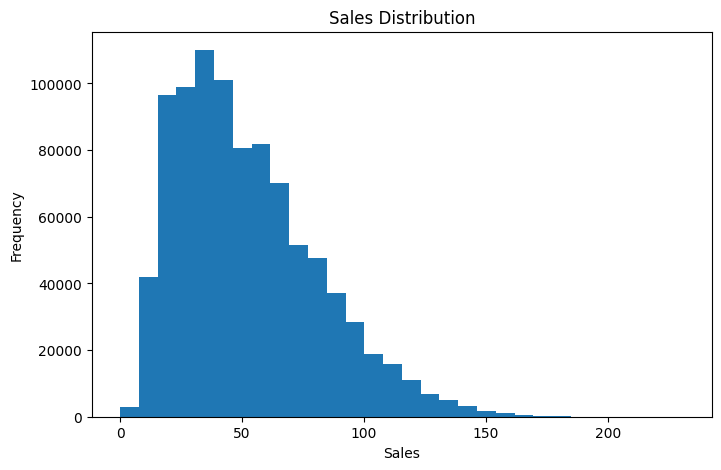

Percentage of zero sales: 1.095290251916758e-06


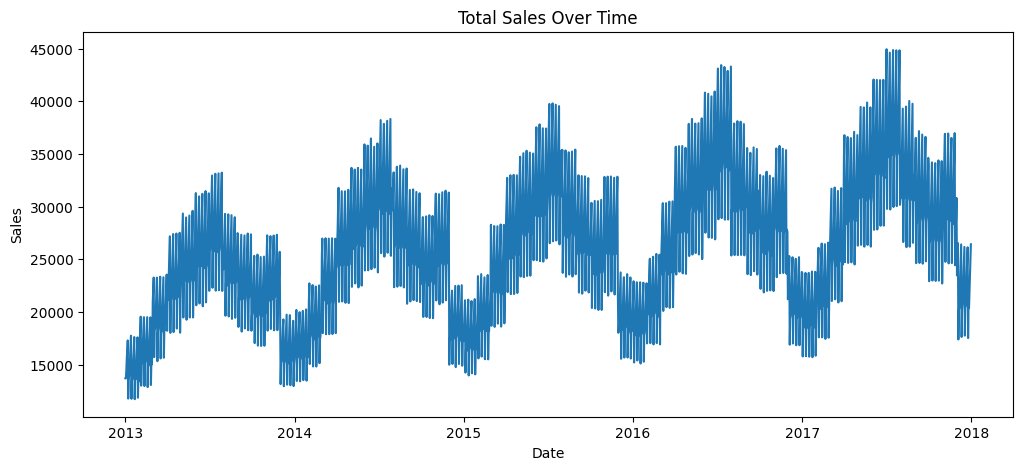

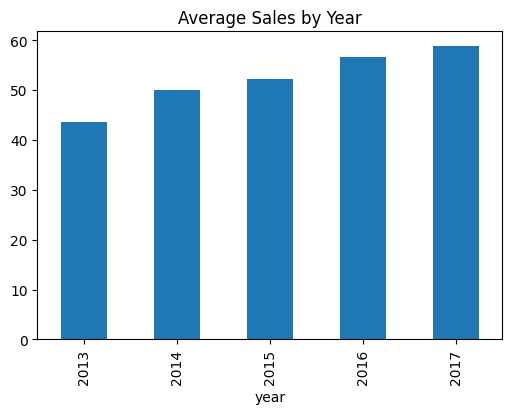

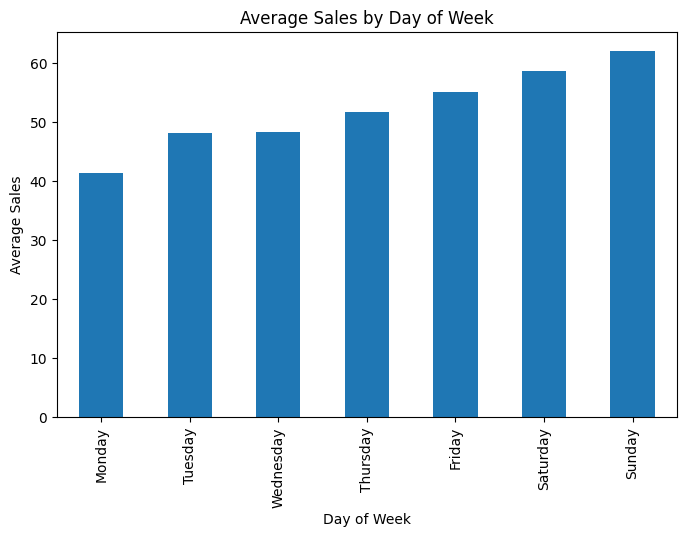

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data

df = pd.read_csv(r"data/raw/train.csv")

# Data info
print("\n---- Data Info ----")
print(df.info())

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# Check missing values
print("\n---- Missing Values ----")
print(df.isnull().sum())

# Summary statistics
print("\n---- Summary Stats ----")
print(df.describe())


print("Number of Stores:", df["store"].nunique())
print("Number of Products:", df["item"].nunique())
print("Total Series:", df.groupby(["store","item"]).ngroups)


# Sales distribution
plt.figure(figsize=(8,5))
plt.hist(df["sales"], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Total sales over time
daily_sales = df.groupby("date")["sales"].sum().reset_index()

# Percentage of zero sales
zero_pct = (df["sales"] == 0).mean()
print("Percentage of zero sales:", zero_pct)

plt.figure(figsize=(12,5))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Average Sales by Year
df["year"] = df["date"].dt.year
yearly = df.groupby("year")["sales"].mean()

plt.figure(figsize=(6,4))
yearly.plot(kind="bar")
plt.title("Average Sales by Year")
plt.show()


# Weekly seasonality (average sales by day of week)
df["day_of_week"] = df["date"].dt.day_name()

weekly = df.groupby("day_of_week")["sales"].mean().reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(8,5))
weekly.plot(kind="bar")
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.show()

# Save cleaned data (optional)
df = df.sort_values(["store", "item", "date"])

df.to_csv(r"data/processed/cleaned_sales.csv", index=False)
# files.download("cleaned_sales.csv")


